Dataset shape: (569, 32)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst perimeter  wor

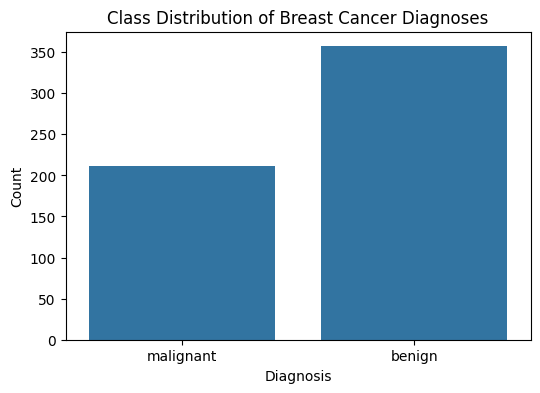

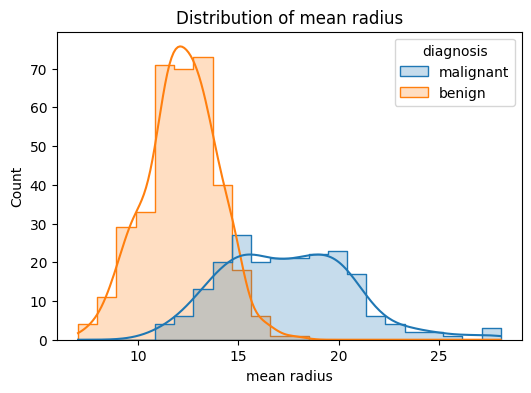

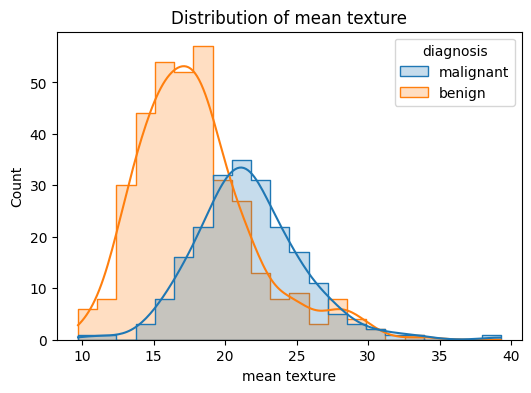

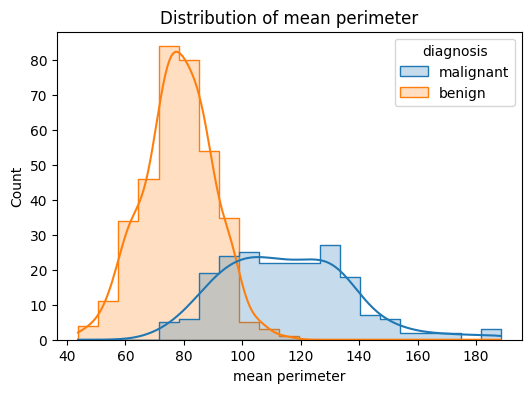

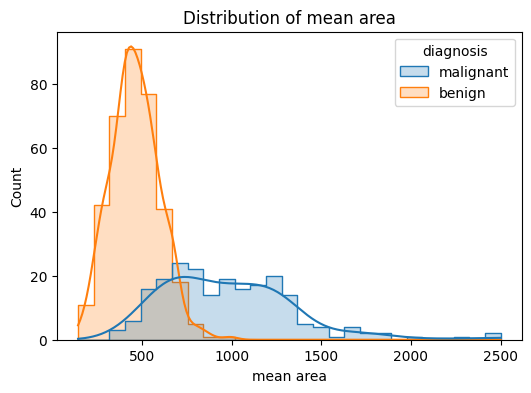

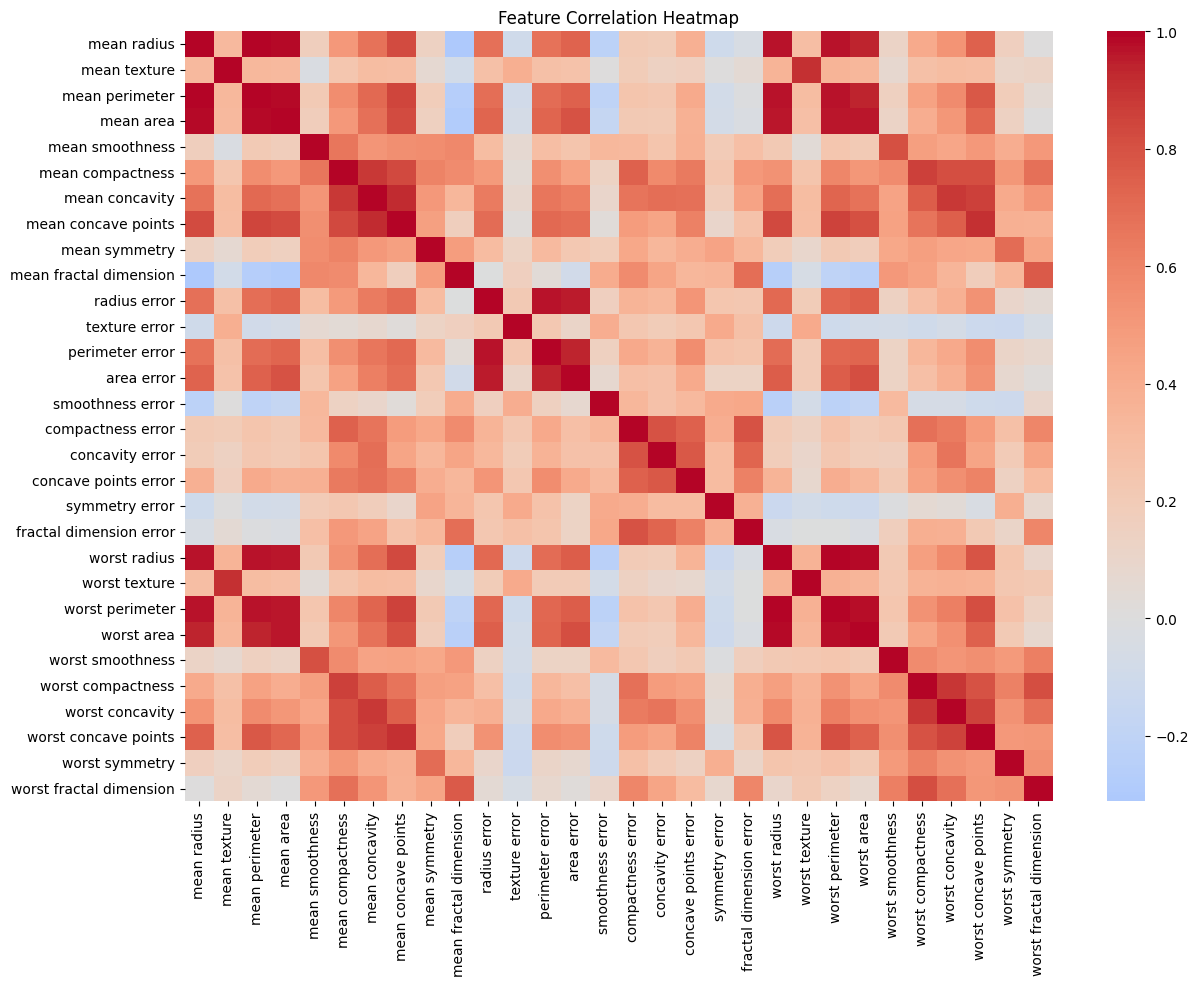


Model Evaluation
----------------------------------------
Accuracy : 0.9298
Precision: 0.9444
Recall   : 0.9444
F1-score : 0.9444

Classification Report:

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



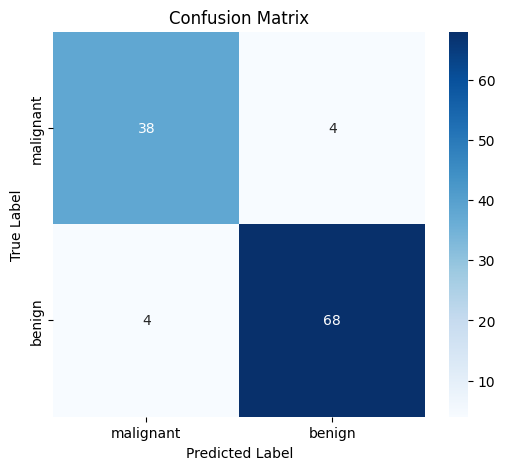

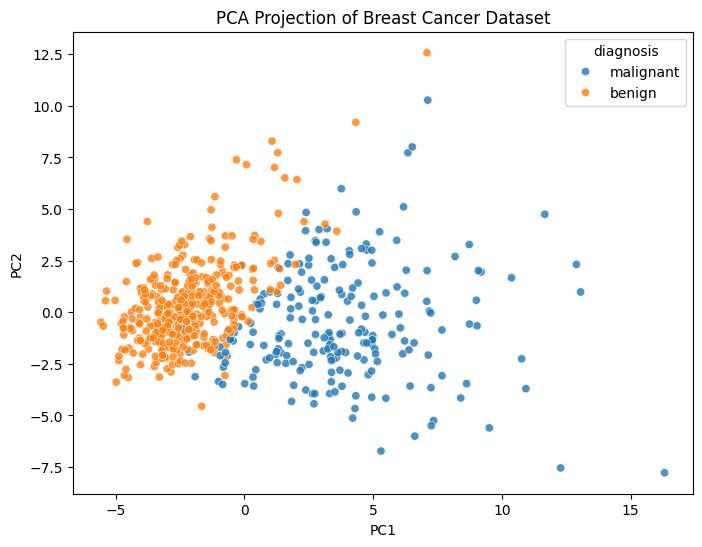


Sample Predictions:
  Actual Label Predicted Label
0    malignant       malignant
1       benign          benign
2    malignant       malignant
3       benign          benign
4    malignant       malignant
5       benign          benign
6       benign          benign
7    malignant       malignant
8    malignant       malignant
9    malignant       malignant


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#loading dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names  #['malignant', 'benign']

#Creating DataFrame (better visualization)
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nClass distribution:")
print(df["diagnosis"].value_counts())

#class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis")
plt.title("Class Distribution of Breast Cancer Diagnoses")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

#Features visualization
selected_features = ["mean radius", "mean texture", "mean perimeter", "mean area"]

for feature in selected_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=feature, hue="diagnosis", kde=True, element="step")
    plt.title(f"Distribution of {feature}")
    plt.show()

#correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.drop(columns=["target", "diagnosis"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Gaussian Naive Bayes (from scratch)
class GaussianNaiveBayes:
    def __init__(self):
        self.classes = None
        self.priors = {}
        self.means = {}
        self.variances = {}

    def fit(self, X, y):
        self.classes = np.unique(y)

        for c in self.classes:
            X_c = X[y == c]

            # Prior probability P(c)
            self.priors[c] = X_c.shape[0] / X.shape[0]

            # Mean and variance for each feature
            self.means[c] = np.mean(X_c, axis=0)
            self.variances[c] = np.var(X_c, axis=0)

            # Avoid division by zero
            self.variances[c][self.variances[c] == 0] = 1e-9

    def gaussian_pdf(self, class_idx, x):
        mean = self.means[class_idx]
        var = self.variances[class_idx]

        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)

        return numerator / denominator

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = []

            for c in self.classes:
                log_prior = np.log(self.priors[c])
                log_likelihood = np.sum(np.log(self.gaussian_pdf(c, x) + 1e-9))
                posterior = log_prior + log_likelihood
                posteriors.append(posterior)

            predictions.append(self.classes[np.argmax(posteriors)])

        return np.array(predictions)

#Model Training
gnb = GaussianNaiveBayes()
gnb.fit(X_train, y_train)

#prediction
y_pred = gnb.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# PCA Visualization
# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["diagnosis"] = pd.Series(y).map({0: "malignant", 1: "benign"})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="diagnosis", alpha=0.8)
plt.title("PCA Projection of Breast Cancer Dataset")
plt.show()

#Compare Actual vs Predicted
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results_df["Actual Label"] = results_df["Actual"].map({0: "malignant", 1: "benign"})
results_df["Predicted Label"] = results_df["Predicted"].map({0: "malignant", 1: "benign"})

print("\nSample Predictions:")
print(results_df[["Actual Label", "Predicted Label"]].head(10))